# CN5 - PROPAGATION D'UN PAQUET D'ONDE

## A) Rappel théorique

On souhaite étudier la propagation d’une onde au cours du temps. Une
onde plane complexe quelconque $\underline{s}(x,t)$ peut se mettre sous
la forme
$$\boxed{\underline{s}(x,t) =\int_{-\infty}^{+\infty}\underline{A}(k)e^{i(\omega t-kx)}\mathrm{d} k,}$$
où $\underline{A}(k)$ désigne l’amplitude spectrale en vecteur d’onde
$k$. Cette fonction est supposée être centrée en $k_0$ et de largeur
typique $\Delta k$. Nous prendrons à titre d’exemple une fonction
gaussienne réelle, de la forme
$$\underline{A}(k) = A(k) = A_0 e^{-(k-k_0)^2/\Delta k^2}.$$

## B) Étude numérique

>**Question 1**
>
> Compléter le script suivant pour définir un tableau `numpy`
    représentant la fonction $A(k)$. On prendra $A_0=1$.

In [1]:
import numpy as np
N    = 2**12     # Nombre de valeurs de k et de x
xmin = -20       # valeur minimale de x
xmax = 20        # valeur maximale de x
L    = xmax-xmin # Longueur de l'intervalle
X    = np.linspace(xmin, xmax, N)   # tableau des x
k    = np.linspace(0,2*np.pi*N/L,N) # tableau des k

k0     = 6
deltak = 2
A      = np.array([np.exp(-((k[i]-k0)/deltak)**2) for i in range(N)])

>**Question 2**
>
> Quelle est l’expression de $\underline{s}(x,t=0)$ en fonction de
>  $A(k)$ ? Compléter le script suivant pour définir une fonction
>   `s_ini` qui renvoie tableau `numpy` représentant la fonction réelle
>   $s(x,t=0)$.

In [2]:
def s_ini(k, X, A):
        s = np.zeros(len(X), dtype=np.complex_)
        for i in range(N):
            s += np.array(A[i]) * np.exp(1j * k[i] * X)
        return np.real(s)

> **Question 3**
> 
> En s'aidant de la bibliothèque `matplotlib`, représenter la dépendance spatiale de l'onde initiale sur un graphe où $x$ est porté en abscisse et $s(x,t=0)$ en ordonnée.  Commenter sur le lien entre la dépendance spatiale de l'onde initiale $s(x,t=0)$ et l'amplitude spectrale $A(k)$.

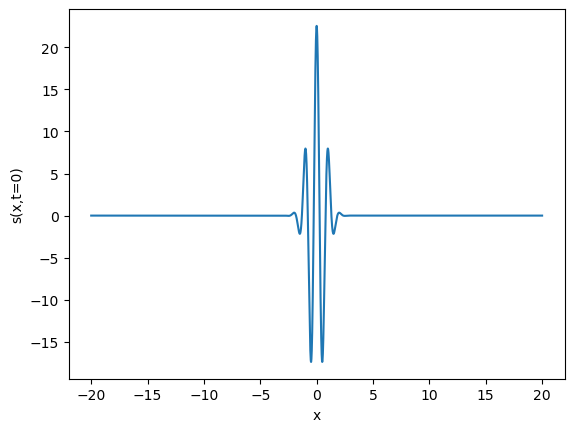

In [3]:
import matplotlib.pyplot as plt

s0 = s_ini(k, X, A)
plt.figure()
plt.plot(X, s0)
plt.xlabel('x')
plt.ylabel('s(x,t=0)')
plt.show()
plt.close()

>**Question 4**
> 
> On suppose maintenant que $\Delta k \ll k_0$, de sorte qu’on puisse
    approximer la relation de dispersion comme
    $\omega(k) \simeq \omega_0 + (k-k_0)v_g$, où  $v_g$ représente la vitesse de groupe. Montrer alors que le paquet d’onde s’écrit
    $$\boxed{\underline{s}(x,t)
       \simeq e^{i(\omega_0 t-k_0 x)}\int_{-\frac{\Delta k}{2}}^{+\frac{\Delta k}{2}}A(k + k_0)e^{-i k (x-v_g t )}\mathrm{d} k.}$$
    Commenter la forme de cette fonction, et justifier que dans cette
    approximation un paquet d’onde ne se déforme pas au cours de sa
    propagation.

>**Question 5**
>
> On étudie la relation de dispersion $\omega(k)$
    du plasma dans le régime haute fréquence $\omega>\omega_p$, où k est réel. Compléter le script suivant pour définir une fonction
    `s_temps` qui renvoie un tableau `numpy` représentant la fonction
    $s(x,t)$. Afficher le paquet d’onde pour la valeur $\Delta k = 2$ choisie précédemment, aux instant $t=5$, $t=10$, et $t=15$. La linéarisation de la relation de dispersion est-elle valable avec les valeurs de $\Delta k$, $c$, $\omega_p$ et $A_0$ utilisées ici ? Observer la déformation du paquet d’onde. 

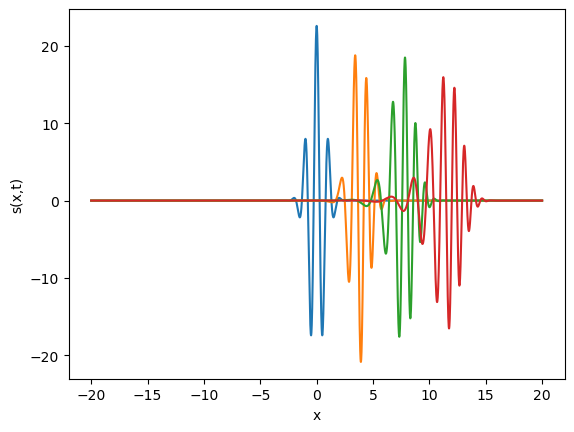

In [4]:
def omega(k):
    omegap = 5
    c = 1
    return (k**2*c**2+omegap**2)**0.5

def s_temps(k, X, A, t):
    s = np.zeros(len(X), dtype=np.complex_)
    for i in range(len(k)):
        s += np.array(A[i]) * np.exp(1j * k[i] * X) * np.exp(-1j * omega(k[i]) * t)
    return np.real(s)


plt.plot(X, s0)
for t in [5,10,15]:
    st = s_temps(k, X, A, t)
    plt.plot(X, st)
plt.xlabel('x')
plt.ylabel('s(x,t)')
plt.show()
plt.close()